In [119]:
import numpy as np
import pandas as pd
import yahooquery as yq
from sklearn.metrics import mean_squared_error, root_mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import TimeSeriesSplit
import seaborn as sns
import matplotlib.pyplot as plt

# Load & Prep Data

In [120]:
sentiment_df = pd.read_csv("../data/daily-sentiment-comments.csv").rename(columns={"created_date": "date"})
sentiment_df["date"] = pd.to_datetime(sentiment_df["date"])
sentiment_df.sample(5)

,date,final_score,score
3872,2023-03-31,-0.158852,4.4
3130,2021-03-19,-0.038412,4.0
1774,2017-07-01,-0.487619,8.8
451,2013-11-07,-0.365297,2.0
152,2012-10-01,0.000000,2.5


In [121]:
# https://www.matteoiacoviello.com/gpr.htm
# GPRD - Daily GPR (Index: 1985:2019=100)
# GPRD_ACT - Daily GPR Acts (Index: 1985:2019=100)
# GPRD_THREAT - Daily GPR Threats (Index: 1985:2019=100)
gpr_df = pd.read_stata("../data/gpr_daily.dta", columns=["date", "GPRD", "GPRD_ACT", "GPRD_THREAT"])
gpr_df.head()

,date,GPRD,GPRD_ACT,GPRD_THREAT
0,1985-01-01,230.039429,275.197601,153.027985
1,1985-01-02,115.676971,146.772064,87.444572
2,1985-01-03,97.428459,158.937653,29.459934
3,1985-01-04,157.366638,156.882248,157.026352
4,1985-01-05,81.361313,92.698143,77.319405


In [122]:
vix = yq.Ticker("^VIX").history(interval="1d", start="2012-01-01", end="2026-01-01").reset_index()
vix["date"] = pd.to_datetime(vix["date"])
vix = vix.drop(columns=["symbol", "open", "high", "low", "close", "volume"])
vix.head()

,date,adjclose
0,2012-01-03,22.969999
1,2012-01-04,22.219999
2,2012-01-05,21.480000
3,2012-01-06,20.629999
4,2012-01-09,21.070000


In [123]:
# merge vix and sentiment and gpr
df = vix \
    .merge(sentiment_df, on="date", how="left") \
    .merge(gpr_df, on="date", how="left") \
    .dropna()
df = df.sort_values("date").reset_index(drop=True)

# add log return
df["log_return"] = np.log(df["adjclose"]).diff()
df = df.dropna()

# note: this data is unshifted t_adjclose = t_final_score = t_score
df.head()

,date,adjclose,final_score,score,GPRD,GPRD_ACT,GPRD_THREAT,log_return
1,2012-04-17,18.459999,0.000000,3.333333,117.745300,117.382874,97.908905,-0.081126
2,2012-04-19,18.360001,0.000000,2.000000,65.094124,36.052086,90.213005,-0.005432
3,2012-04-23,18.969999,0.178730,2.000000,90.460236,85.887421,78.802452,0.032684
4,2012-04-24,18.100000,-0.077251,2.600000,93.368942,64.752380,114.770996,-0.046947
5,2012-04-25,16.820000,-0.272216,2.800000,83.951027,125.538933,58.173260,-0.073343


# SARIMA

## Prep Data

In [124]:
lag_cols = ["GPRD_THREAT", "GPRD_ACT", "GPRD", "final_score"]
for col in lag_cols:
    df[col] = df[col].shift(1)

df = df.dropna().reset_index(drop=True)

In [125]:
def build_rolling_features(series: pd.Series) -> pd.DataFrame:
    """Compute rolling stats from a log_return series. Backward-looking only."""
    out = pd.DataFrame(index=series.index)
    for window, label in [(21, "3w"), (42, "6w"), (365, "1y")]:
        out[f"{label}_rolling_mean"] = series.rolling(window, min_periods=window).mean()
        out[f"{label}_rolling_std"]  = series.rolling(window, min_periods=window).std()
    return out

C:\miniforge3\envs\machine-learning\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\miniforge3\envs\machine-learning\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\miniforge3\envs\machine-learning\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


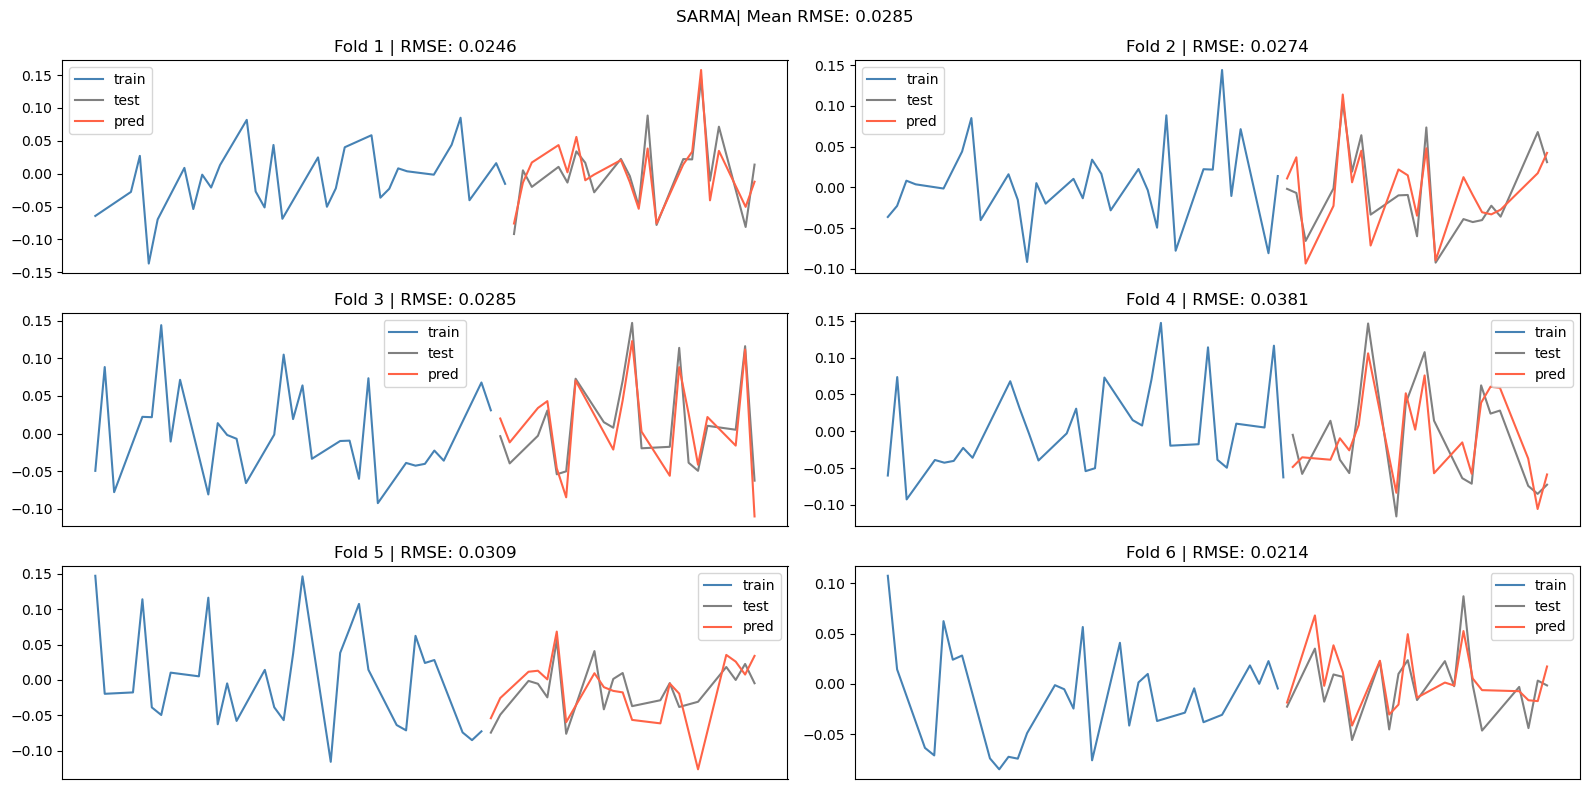

In [126]:
exog_static = ["GPRD_THREAT", "GPRD_ACT", "GPRD", "final_score"]  # already lagged

n_splits  = 6
test_size = 20
tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)

scores = []
fig, axes = plt.subplots(figsize=(16, 8), nrows=3, ncols=2)
axes = axes.flatten()

y_full = df["log_return"]

for fold, (train_idx, test_idx) in enumerate(tscv.split(df)):

    # ── a. Build rolling features on TRAIN data only ────────────────
    # We need enough history for the longest window (365), so the
    # effective training set starts after that warm-up.
    train_series = y_full.iloc[train_idx]
    rolling_train = build_rolling_features(train_series)

    # For the TEST set, we extend the series through the test period
    # but compute rolling windows using the full history up to each
    # test point (expanding / walk-forward). No future data is used
    # because rolling() only looks backward.
    full_series = y_full.iloc[np.concatenate([train_idx, test_idx])]
    rolling_full = build_rolling_features(full_series)

    # Slice out train / test portions
    rolling_train = rolling_full.iloc[: len(train_idx)]
    rolling_test  = rolling_full.iloc[len(train_idx) :]

    # ── b. Assemble exog matrices ───────────────────────────────────
    X_train = pd.concat(
        [rolling_train, df.loc[train_idx, exog_static].reset_index(drop=True)],
        axis=1,
    )
    X_test = pd.concat(
        [rolling_test.reset_index(drop=True),
         df.loc[test_idx, exog_static].reset_index(drop=True)],
        axis=1,
    )

    y_train = train_series.reset_index(drop=True)
    y_test  = y_full.iloc[test_idx].reset_index(drop=True)

    # Drop rows where rolling windows haven't warmed up yet
    valid = X_train.dropna().index
    X_train = X_train.loc[valid]
    y_train = y_train.loc[valid]

    # ── c. Difference X (statsmodels SARIMA only differences y internally) ───────
    X_train_d = X_train.diff().iloc[1:]
    y_train_d = y_train.iloc[1:]

    X_test_d = pd.concat([X_train.iloc[[-1]], X_test]).diff().iloc[1:]
    # ↑ prepend last train row so the first test diff is correct

    # ── d. Fit & forecast ───────────────────────────────────────────
    model = SARIMAX(
        y_train_d,
        exog=X_train_d,
        order=(7, 0, 2),
        enforce_invertibility=False,
        enforce_stationarity=False,
        trend="c",
    )
    fitted  = model.fit(disp=False, maxiter=10_000)
    y_preds = fitted.forecast(steps=len(X_test_d), exog=X_test_d)

    # ── e. Plot ─────────────────────────────────────────────────────
    ax = axes[fold]
    dates_train = df["date"].iloc[train_idx].values
    dates_test  = df["date"].iloc[test_idx].values

    show = min(30, len(train_idx))
    sns.lineplot(x=dates_train[-show:], y=y_full.iloc[train_idx[-show:]].values,
                 label="train", color="steelblue", ax=ax)
    sns.lineplot(x=dates_test, y=y_test.values,
                 label="test", color="grey", ax=ax)
    sns.lineplot(x=dates_test, y=y_preds.values,
                 label="pred", color="tomato", ax=ax)

    ax.set_xticks([])
    rmse = np.sqrt(mean_squared_error(y_test, y_preds))
    scores.append(rmse)
    ax.set_title(f"Fold {fold + 1} | RMSE: {rmse:.4f}")
    ax.legend()

plt.suptitle(f"SARMA| Mean RMSE: {np.mean(scores):.4f}")
plt.tight_layout()
plt.show()

# ML Forecast

In [127]:
from mlforecast import MLForecast
from mlforecast.lag_transforms import ExpandingMean, RollingMean, SeasonalRollingMean, RollingStd
from mlforecast.target_transforms import Differences, LocalStandardScaler

# models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [128]:
df.head()

,date,adjclose,final_score,score,GPRD,GPRD_ACT,GPRD_THREAT,log_return
0,2012-04-19,18.360001,0.000000,2.0,117.745300,117.382874,97.908905,-0.005432
1,2012-04-23,18.969999,0.000000,2.0,65.094124,36.052086,90.213005,0.032684
2,2012-04-24,18.100000,0.178730,2.6,90.460236,85.887421,78.802452,-0.046947
3,2012-04-25,16.820000,-0.077251,2.8,93.368942,64.752380,114.770996,-0.073343
4,2012-04-26,16.240000,-0.272216,2.4,83.951027,125.538933,58.173260,-0.035091


In [129]:
df_log_return = df.drop(columns=["adjclose", "score"]).rename(columns={"log_return": "y", "date": "ds"})
df_log_return["unique_id"] = "log_return"

# fill missing business days with forward-fill
df_log_return = df_log_return.set_index('ds').asfreq('B', method='ffill').reset_index()

df_log_return.head()

,ds,final_score,GPRD,GPRD_ACT,GPRD_THREAT,y,unique_id
0,2012-04-19,0.000000,117.745300,117.382874,97.908905,-0.005432,log_return
1,2012-04-20,0.000000,117.745300,117.382874,97.908905,-0.005432,log_return
2,2012-04-23,0.000000,65.094124,36.052086,90.213005,0.032684,log_return
3,2012-04-24,0.178730,90.460236,85.887421,78.802452,-0.046947,log_return
4,2012-04-25,-0.077251,93.368942,64.752380,114.770996,-0.073343,log_return


In [130]:
exog_cols = ["GPRD_THREAT", "GPRD_ACT", "GPRD", "final_score"]
for col in exog_cols:
    df_log_return[col] = df_log_return.groupby("unique_id")[col].shift(1)

df_log_return = df_log_return.dropna().reset_index(drop=True)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000251 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4590
[LightGBM] [Info] Number of data points in the train set: 2889, number of used features: 18
[LightGBM] [Info] Start training from score -0.001294
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000167 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4590
[LightGBM] [Info] Number of data points in the train set: 2909, number of used features: 18
[LightGBM] [Info] Start training from score -0.001249
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000192 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4590
[LightGBM] [Info] Number of data points in the train set: 2929, number of used features: 18
[LightGBM] [Info] Start trai

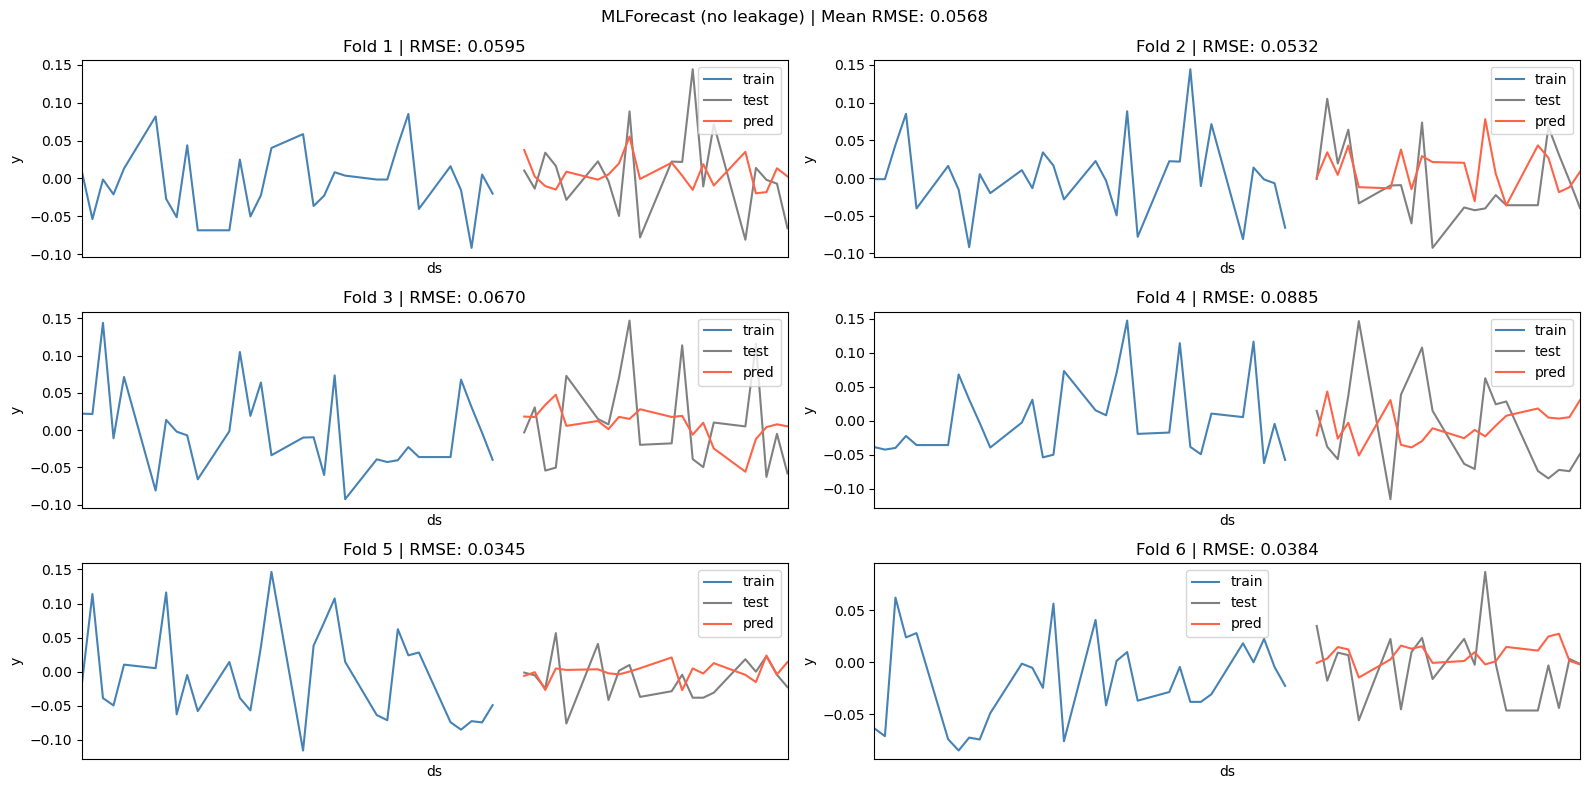

In [131]:
n_splits = 6
test_size = 20
tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)

scores = []
fig, axes = plt.subplots(figsize=(16, 8), nrows=3, ncols=2)
axes = axes.flatten()

for fold, (train_idx, test_idx) in enumerate(tscv.split(df_log_return)):
    train_df = df_log_return.iloc[train_idx].copy()
    test_df = df_log_return.iloc[test_idx].copy()

    # MLForecast computes lag transforms internally from training data
    # only — no leakage by design. We just need to match the SARIMA
    # rolling windows: 21, 42, 365.
    fcst = MLForecast(
        models=[LGBMRegressor(random_state=42)],
        freq="B",
        lags=[1, 5, 10, 15, 20, 25, 30, 35, 40],
        lag_transforms={
            1: [
                ExpandingMean(),
                RollingMean(21),   # ≈ 3w rolling mean
                RollingMean(42),   # ≈ 6w rolling mean
                RollingStd(21),    # ≈ 3w rolling std
                RollingStd(42),    # ≈ 6w rolling std
            ],
        },
    )

    fcst.fit(train_df, static_features=[])

    h = len(test_idx)
    X_test = test_df[["unique_id", "ds"] + exog_cols]
    y_preds = fcst.predict(h=h, X_df=X_test)

    y_pred_values = y_preds["LGBMRegressor"].values
    y_test_values = test_df["y"].values

    # ── Plot ────────────────────────────────────────────────────────
    ax = axes[fold]
    train_show_idx = train_idx[-30:]

    sns.lineplot(x=df_log_return["ds"].iloc[train_show_idx],
                 y=df_log_return["y"].iloc[train_show_idx],
                 label="train", color="steelblue", ax=ax)
    sns.lineplot(x=df_log_return["ds"].iloc[test_idx],
                 y=y_test_values,
                 label="test", color="grey", ax=ax)
    sns.lineplot(x=df_log_return["ds"].iloc[test_idx],
                 y=y_pred_values,
                 label="pred", color="tomato", ax=ax)

    ax.set_xlim([df_log_return["ds"].iloc[train_show_idx[0]],
                 df_log_return["ds"].iloc[test_idx[-1]]])
    ax.set_xticks([])

    rmse = np.sqrt(mean_squared_error(y_test_values, y_pred_values))
    scores.append(rmse)
    ax.set_title(f"Fold {fold + 1} | RMSE: {rmse:.4f}")
    ax.legend()

plt.suptitle(f"MLForecast (no leakage) | Mean RMSE: {np.mean(scores):.4f}")
plt.tight_layout()
plt.show()